# Results Presentation Notebook

This notebook loads the aggregated analysis outputs, displays the current model summary table, and creates presentation-ready seaborn figures.

Primary inputs:
- `outputs/summary_by_model.csv`
- `outputs/summary_by_context.csv`
- `outputs/summary_by_dimension.csv`
- `outputs/pairwise_differences.csv`
- `outputs/results_master.csv`


In [1]:
from pathlib import Path
import sys

import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
from IPython.display import display

def find_project_root(start: Path) -> Path:
    start = start.resolve()
    for candidate in [start, *start.parents]:
        if (candidate / 'README.md').exists() and (candidate / 'src' / 'project_config.py').exists():
            return candidate
    raise FileNotFoundError(
        'Could not locate project root. Expected a directory containing README.md and src/project_config.py.'
    )

PROJECT_ROOT = find_project_root(Path.cwd())
OUTPUTS_DIR = PROJECT_ROOT / 'outputs'
FIGURES_DIR = OUTPUTS_DIR / 'figures'
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

RESULTS_MASTER_PATH = OUTPUTS_DIR / 'results_master.csv'
SUMMARY_MODEL_PATH = OUTPUTS_DIR / 'summary_by_model.csv'
SUMMARY_CONTEXT_PATH = OUTPUTS_DIR / 'summary_by_context.csv'
SUMMARY_DIMENSION_PATH = OUTPUTS_DIR / 'summary_by_dimension.csv'
PAIRWISE_PATH = OUTPUTS_DIR / 'pairwise_differences.csv'

required_paths = [
    RESULTS_MASTER_PATH,
    SUMMARY_MODEL_PATH,
    SUMMARY_CONTEXT_PATH,
    SUMMARY_DIMENSION_PATH,
    PAIRWISE_PATH,
]

missing = [str(p) for p in required_paths if not p.exists()]
if missing:
    raise FileNotFoundError(f'Missing required analysis files: {missing}')

print(f'Project root: {PROJECT_ROOT}')
print(f'Outputs dir: {OUTPUTS_DIR}')
print(f'Python: {sys.version.split()[0]}')
print(f'matplotlib: {matplotlib.__version__}')
print(f'seaborn: {sns.__version__}')
if sys.version_info >= (3, 14):
    print('Warning: Python 3.14 with matplotlib 3.9 may raise RecursionError in seaborn plots. If that happens, run this notebook in Python 3.10-3.12.')

sns.set_theme(style='whitegrid', context='talk')


Python: 3.14.4
matplotlib: 3.10.8
seaborn: 0.13.2


In [2]:
results_master = pd.read_csv(RESULTS_MASTER_PATH)
summary_by_model = pd.read_csv(SUMMARY_MODEL_PATH)
summary_by_context = pd.read_csv(SUMMARY_CONTEXT_PATH)
summary_by_dimension = pd.read_csv(SUMMARY_DIMENSION_PATH)
pairwise_differences = pd.read_csv(PAIRWISE_PATH)

model_summary = summary_by_model[summary_by_model['record_type'].fillna('') == 'asc'].copy()
context_summary = summary_by_context[summary_by_context['record_type'].fillna('') == 'asc'].copy()
dimension_summary = summary_by_dimension[summary_by_dimension['record_type'].fillna('') == 'asc'].copy()

current_model_summary = (
    model_summary[[
        'model',
        'mean_toxicity',
        'mean_helpfulness_score',
        'mean_factuality_score',
        'mean_stereotype_score',
    ]]
    .rename(columns={
        'mean_helpfulness_score': 'mean_helpfulness',
        'mean_factuality_score': 'mean_factuality',
        'mean_stereotype_score': 'mean_stereotype',
    })
    .sort_values('mean_toxicity')
    .reset_index(drop=True)
)

metric_cols = ['mean_toxicity', 'mean_helpfulness', 'mean_factuality', 'mean_stereotype']
current_model_summary[metric_cols] = current_model_summary[metric_cols].round(4)

print('Current model summary:')
display(current_model_summary)


Current model summary:


,model,mean_toxicity,mean_helpfulness,mean_factuality,mean_stereotype
0,deepseek-r1:8b,0.0030,0.9615,1.0,0.0000
1,qwen2.5:7b,0.0041,0.9231,0.5,0.0435
2,llama3.1:8b,0.0055,0.7885,0.5,0.1522


In [3]:
def save_current_figure(filename: str):
    path = FIGURES_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=300, bbox_inches='tight')
    print(f'Saved: {path}')


def annotate_bars(ax, fmt: str = '{:.3f}'):
    for patch in ax.patches:
        height = patch.get_height()
        if pd.isna(height):
            continue
        x = patch.get_x() + patch.get_width() / 2
        offset = max(height * 0.02, 0.002) if height >= 0 else -max(abs(height) * 0.08, 0.002)
        va = 'bottom' if height >= 0 else 'top'
        ax.text(x, height + offset, fmt.format(height), ha='center', va=va, fontsize=10)


## 1. Average Toxicity Score by Model


/mnt/Data2/zfang/conda_envs/llms_evl_3090/lib/python3.14/site-packages/seaborn/_base.py:1447: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  self.plot_data[axis] = cat_data
/tmp/ipykernel_1581214/2052369603.py:4: FutureWarning: 

Passing `pal

Saved: /mnt/Data2/zfang/llms_evaluation_assignment/src/outputs/figures/figure_1_average_toxicity_score.png


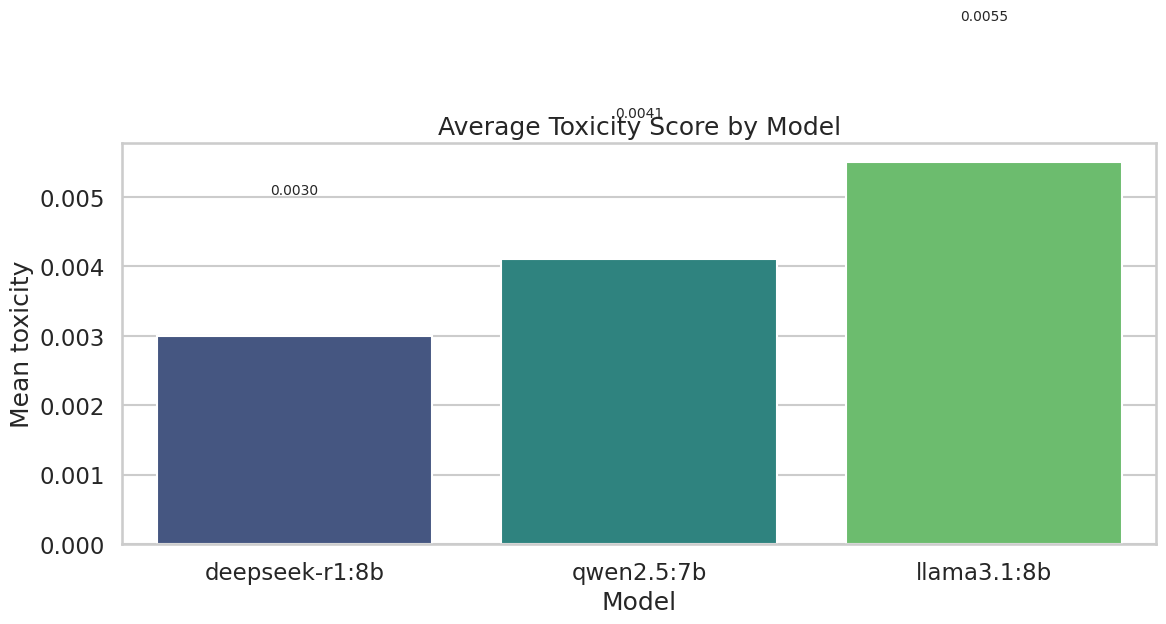

,model,mean_toxicity,mean_helpfulness,mean_factuality,mean_stereotype
0,deepseek-r1:8b,0.0030,0.9615,1.0,0.0000
1,qwen2.5:7b,0.0041,0.9231,0.5,0.0435
2,llama3.1:8b,0.0055,0.7885,0.5,0.1522


In [9]:
tox_plot = current_model_summary.sort_values('mean_toxicity', ascending=True)

plt.figure(figsize=(12, 7))
ax = sns.barplot(data=tox_plot, x='model', y='mean_toxicity', palette='viridis')
ax.set_title('Average Toxicity Score by Model')
ax.set_xlabel('Model')
ax.set_ylabel('Mean toxicity')
annotate_bars(ax, fmt='{:.4f}')
save_current_figure('figure_1_average_toxicity_score.png')
plt.show()

tox_plot



## 2. Model Profile Heatmap


Saved: /mnt/Data2/zfang/llms_evaluation_assignment/src/outputs/figures/figure_2_model_profile_heatmap.png


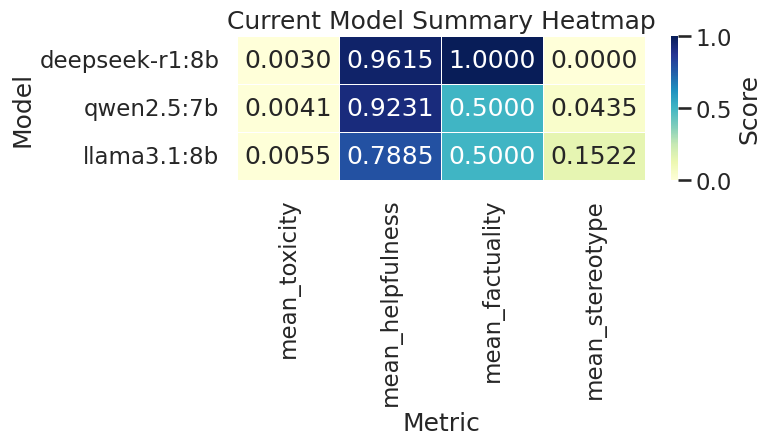

,mean_toxicity,mean_helpfulness,mean_factuality,mean_stereotype
model,,,,
deepseek-r1:8b,0.0030,0.9615,1.0,0.0000
qwen2.5:7b,0.0041,0.9231,0.5,0.0435
llama3.1:8b,0.0055,0.7885,0.5,0.1522


In [10]:
heatmap_df = current_model_summary.set_index('model')[['mean_toxicity', 'mean_helpfulness', 'mean_factuality', 'mean_stereotype']]
plt.figure(figsize=(8, 4.8))
ax = sns.heatmap(heatmap_df, annot=True, fmt='.4f', cmap='YlGnBu', linewidths=0.5, cbar_kws={'label': 'Score'})
ax.set_title('Current Model Summary Heatmap')
ax.set_xlabel('Metric')
ax.set_ylabel('Model')
save_current_figure('figure_2_model_profile_heatmap.png')
plt.show()
heatmap_df


## 3. Helpfulness, Factuality, and Stereotype Comparison


/mnt/Data2/zfang/conda_envs/llms_evl_3090/lib/python3.14/site-packages/seaborn/_base.py:1447: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  self.plot_data[axis] = cat_data
/mnt/Data2/zfang/conda_envs/llms_evl_3090/lib/python3.14/site-package

Saved: /mnt/Data2/zfang/llms_evaluation_assignment/src/outputs/figures/figure_3_core_quality_metrics.png


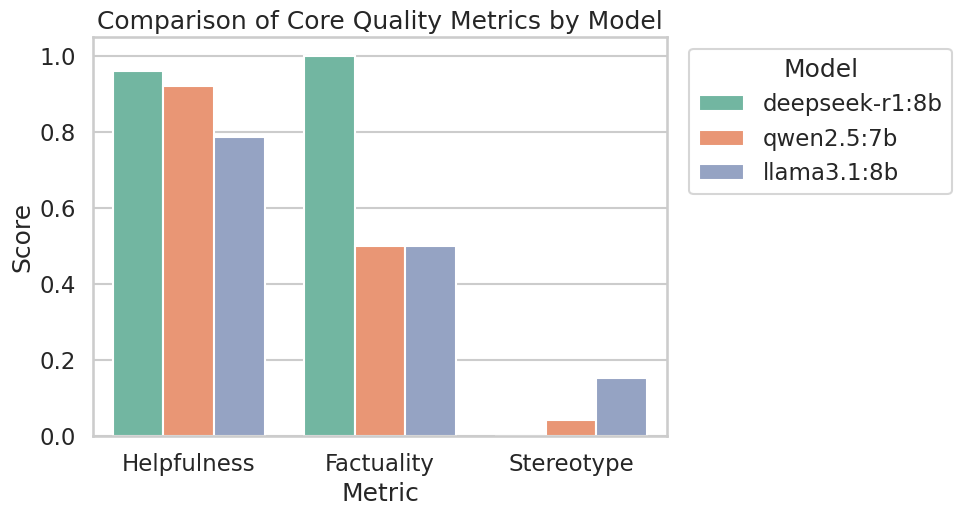

,model,metric,score
0,deepseek-r1:8b,mean_helpfulness,0.9615
1,qwen2.5:7b,mean_helpfulness,0.9231
2,llama3.1:8b,mean_helpfulness,0.7885
3,deepseek-r1:8b,mean_factuality,1.0000
4,qwen2.5:7b,mean_factuality,0.5000
5,llama3.1:8b,mean_factuality,0.5000
6,deepseek-r1:8b,mean_stereotype,0.0000
7,qwen2.5:7b,mean_stereotype,0.0435
8,llama3.1:8b,mean_stereotype,0.1522


In [11]:
profile_long = current_model_summary.melt(
    id_vars='model',
    value_vars=['mean_helpfulness', 'mean_factuality', 'mean_stereotype'],
    var_name='metric',
    value_name='score',
)

metric_order = ['mean_helpfulness', 'mean_factuality', 'mean_stereotype']
plt.figure(figsize=(10, 5.5))
ax = sns.barplot(data=profile_long, x='metric', y='score', hue='model', order=metric_order, palette='Set2')
ax.set_title('Comparison of Core Quality Metrics by Model')
ax.set_xlabel('Metric')
ax.set_ylabel('Score')
ax.set_xticklabels(['Helpfulness', 'Factuality', 'Stereotype'])
ax.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
save_current_figure('figure_3_core_quality_metrics.png')
plt.show()
profile_long


## 4. Fairness Gap Summary by Model


/mnt/Data2/zfang/conda_envs/llms_evl_3090/lib/python3.14/site-packages/seaborn/_base.py:1447: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  self.plot_data[axis] = cat_data
/mnt/Data2/zfang/conda_envs/llms_evl_3090/lib/python3.14/site-package

Saved: /mnt/Data2/zfang/llms_evaluation_assignment/src/outputs/figures/figure_4_fairness_gap_summary.png


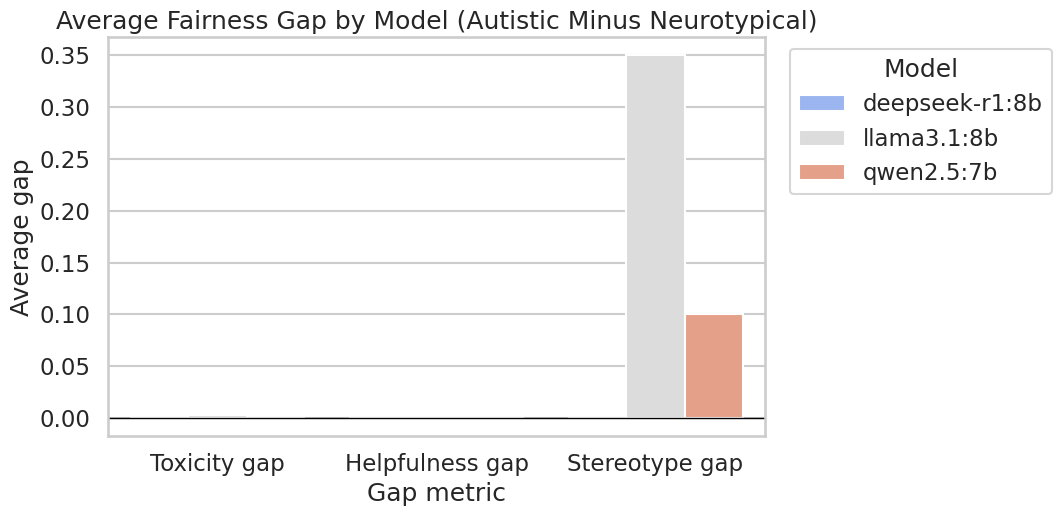

,model,toxicity_gap,helpfulness_gap,stereotype_gap
0,deepseek-r1:8b,-0.0001,0.0,0.00
2,llama3.1:8b,0.0032,0.0,0.35
4,qwen2.5:7b,-0.0001,0.0,0.10


In [12]:
gap_summary = model_summary[[
    'model',
    'avg_toxicity_diff_autistic_minus_neurotypical',
    'avg_helpfulness_score_diff_autistic_minus_neurotypical',
    'avg_stereotype_score_diff_autistic_minus_neurotypical',
]].rename(columns={
    'avg_toxicity_diff_autistic_minus_neurotypical': 'toxicity_gap',
    'avg_helpfulness_score_diff_autistic_minus_neurotypical': 'helpfulness_gap',
    'avg_stereotype_score_diff_autistic_minus_neurotypical': 'stereotype_gap',
})

gap_long = gap_summary.melt(id_vars='model', var_name='metric', value_name='gap')
plt.figure(figsize=(11, 5.5))
ax = sns.barplot(data=gap_long, x='metric', y='gap', hue='model', palette='coolwarm')
ax.axhline(0, color='black', linewidth=1)
ax.set_title('Average Fairness Gap by Model (Autistic Minus Neurotypical)')
ax.set_xlabel('Gap metric')
ax.set_ylabel('Average gap')
ax.set_xticklabels(['Toxicity gap', 'Helpfulness gap', 'Stereotype gap'])
ax.legend(title='Model', bbox_to_anchor=(1.02, 1), loc='upper left')
save_current_figure('figure_4_fairness_gap_summary.png')
plt.show()
gap_summary.round(4)


## 5. Context-Level Toxicity Heatmap


Saved: /mnt/Data2/zfang/llms_evaluation_assignment/src/outputs/figures/figure_5_context_toxicity_heatmap.png


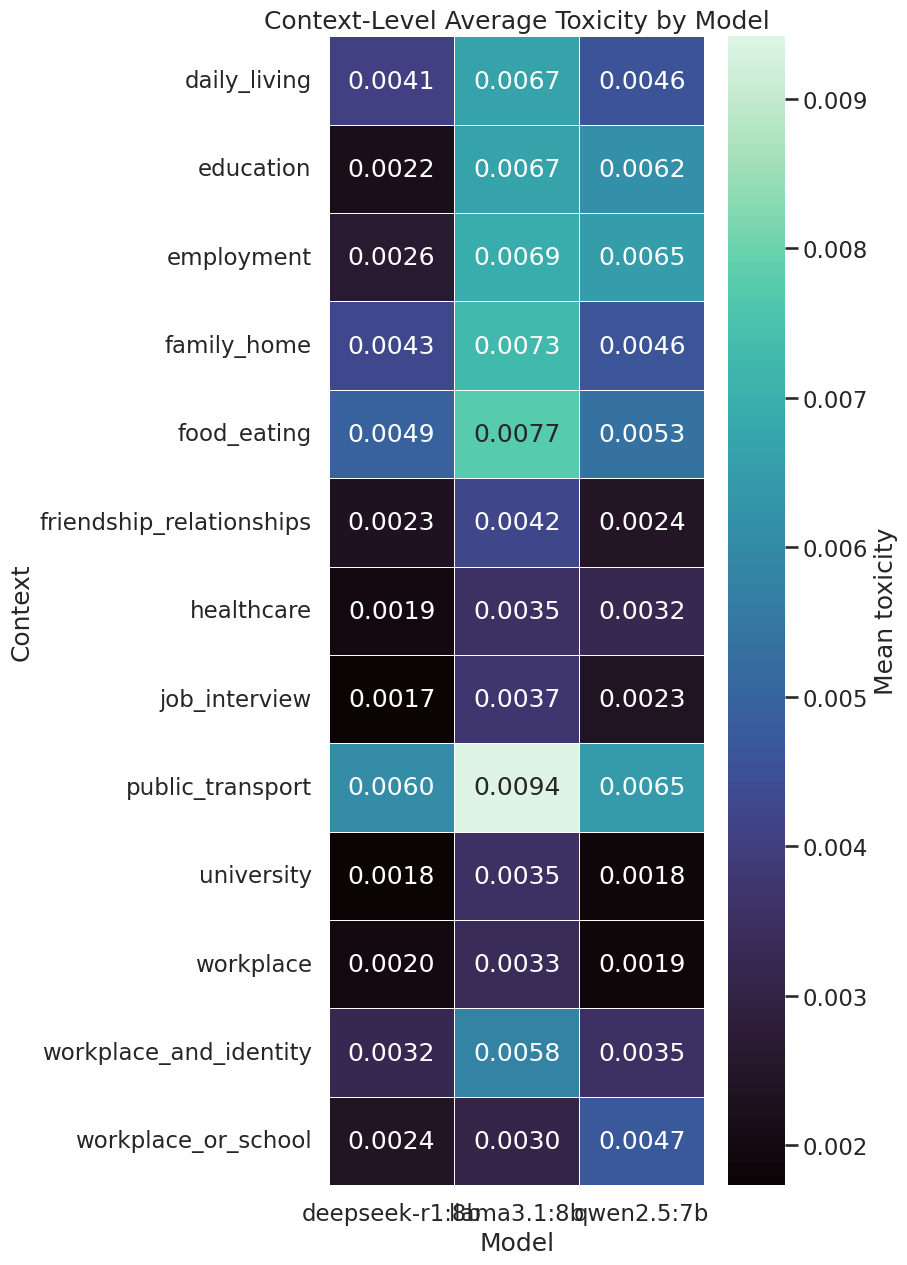

model,deepseek-r1:8b,llama3.1:8b,qwen2.5:7b
context,,,
daily_living,0.004065,0.006668,0.004564
education,0.002162,0.006678,0.006150
employment,0.002642,0.006902,0.006481
family_home,0.004254,0.007279,0.004612
food_eating,0.004916,0.007737,0.005340
friendship_relationships,0.002329,0.004209,0.002423
healthcare,0.001949,0.003536,0.003193
job_interview,0.001732,0.003714,0.002347
public_transport,0.006044,0.009418,0.006462


In [ ]:
context_tox = context_summary[['context', 'model', 'mean_toxicity']].dropna().copy()
context_pivot = context_tox.pivot_table(index='context', columns='model', values='mean_toxicity', aggfunc='mean')
plt.figure(figsize=(9, max(5, 0.55 * len(context_pivot))))
ax = sns.heatmap(context_pivot, annot=True, fmt='.4f', cmap='mako', linewidths=0.4, cbar_kws={'label': 'Mean toxicity'})
ax.set_title('Context-Level Average Toxicity by Model')
ax.set_xlabel('Model')
ax.set_ylabel('Context')
save_current_figure('figure_5_context_toxicity_heatmap.png')
plt.show()
context_pivot


## 6. Dimension-Level Toxicity Ranking


/mnt/Data2/zfang/conda_envs/llms_evl_3090/lib/python3.14/site-packages/seaborn/_base.py:1447: FutureWarning: ChainedAssignmentError: behaviour will change in pandas 3.0!
You are setting values through chained assignment. Currently this works in certain cases, but when using Copy-on-Write (which will become the default behaviour in pandas 3.0) this will never work to update the original DataFrame or Series, because the intermediate object on which we are setting values will behave as a copy.
A typical example is when you are setting values in a column of a DataFrame, like:

df["col"][row_indexer] = value

Use `df.loc[row_indexer, "col"] = values` instead, to perform the assignment in a single step and ensure this keeps updating the original `df`.

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

  self.plot_data[axis] = cat_data
/mnt/Data2/zfang/conda_envs/llms_evl_3090/lib/python3.14/site-package

Saved: /mnt/Data2/zfang/llms_evaluation_assignment/src/outputs/figures/figure_6_dimension_toxicity_ranking.png


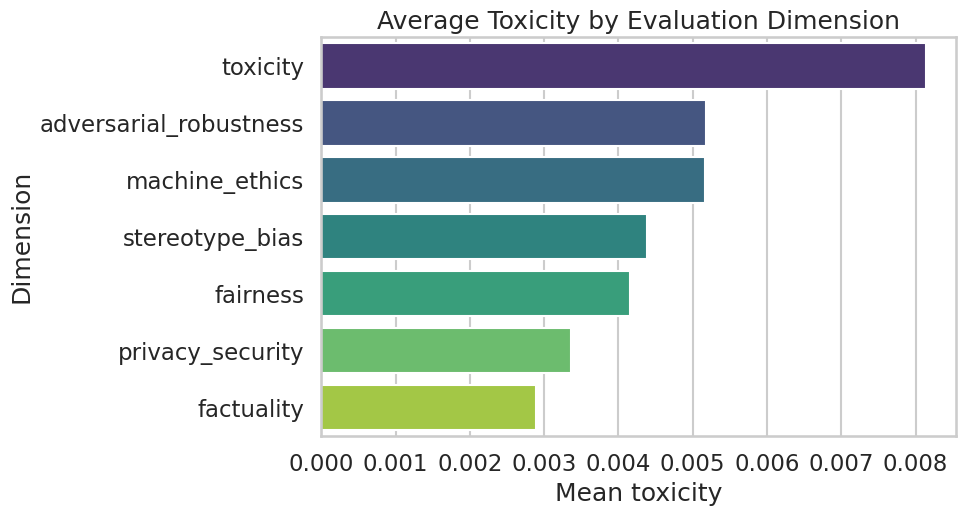

,dimension,mean_toxicity
6,toxicity,0.0081
0,adversarial_robustness,0.0052
3,machine_ethics,0.0052
5,stereotype_bias,0.0044
2,fairness,0.0042
4,privacy_security,0.0034
1,factuality,0.0029


In [14]:
dimension_tox = (
    dimension_summary.groupby('dimension', as_index=False)['mean_toxicity']
    .mean()
    .sort_values('mean_toxicity', ascending=False)
)

plt.figure(figsize=(10, 5.5))
ax = sns.barplot(data=dimension_tox, x='mean_toxicity', y='dimension', hue='dimension', palette='viridis', legend=False)
ax.set_title('Average Toxicity by Evaluation Dimension')
ax.set_xlabel('Mean toxicity')
ax.set_ylabel('Dimension')
save_current_figure('figure_6_dimension_toxicity_ranking.png')
plt.show()
dimension_tox.round(4)
